In [4]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Clustering Models
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

# Machine Learning - Metrics
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score,
    confusion_matrix
)

# Dimensionality Reduction
from sklearn.manifold import TSNE

# Optimal cluster-label assignment
from scipy.optimize import linear_sum_assignment

# Utilities
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print('All libraries imported successfully!')


All libraries imported successfully!


# =====================================================================

# Unsupervised Clustering — Multi-Class Anomaly Type Discovery

# =====================================================================


This notebook applies **unsupervised clustering** to discover the 8 anomaly types in 5G network KPI data.
No labels are used during model training — the `anomaly_type` column is used **only as an oracle** during evaluation.

**Models:** K-Means · DBSCAN · Gaussian Mixture Model (GMM) · Agglomerative Clustering

**Evaluation:** Silhouette Score · Davies-Bouldin Index · Adjusted Rand Index (ARI) · Normalized Mutual Information (NMI)

**Mapping:** Hungarian algorithm — optimal cluster-to-anomaly-type assignment

**Visualisation:** PCA · t-SNE · UMAP *(optional)*


## 1. Data Loading

In [5]:
# Batch configuration
DATASET_PATH = Path('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')
USE_BATCH_MODE = True
BATCH_SIZE = 50000
BATCH_NUMBER = 1  # 1 = first batch, 2 = second batch, ...

# Number of clusters: 8 anomaly types + 1 normal class
N_CLUSTERS = 9

print('Batch configuration ready.')
print(f'  Dataset path : {DATASET_PATH}')
print(f'  Batch mode   : {USE_BATCH_MODE}')
if USE_BATCH_MODE:
    print(f'  Batch size   : {BATCH_SIZE:,}')
    print(f'  Batch number : {BATCH_NUMBER}')
print(f'  N_CLUSTERS   : {N_CLUSTERS}  (8 anomaly types + 1 normal class)')


Batch configuration ready.
  Dataset path : /Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv
  Batch mode   : True
  Batch size   : 50,000
  Batch number : 1
  N_CLUSTERS   : 9  (8 anomaly types + 1 normal class)


In [6]:
# Load the dataset or a specific batch
if USE_BATCH_MODE:
    total_rows = sum(1 for _ in DATASET_PATH.open('r', encoding='utf-8')) - 1
    start_row = (BATCH_NUMBER - 1) * BATCH_SIZE

    if start_row >= total_rows:
        raise ValueError(
            f'Batch {BATCH_NUMBER} is out of range. Dataset has {total_rows:,} data rows.'
        )

    rows_to_read = min(BATCH_SIZE, total_rows - start_row)
    df = pd.read_csv(DATASET_PATH, skiprows=range(1, start_row + 1), nrows=rows_to_read)
else:
    total_rows = sum(1 for _ in DATASET_PATH.open('r', encoding='utf-8')) - 1
    df = pd.read_csv(DATASET_PATH)

df['timestamp'] = pd.to_datetime(df['timestamp'])

print('✅ Dataset loaded successfully!')
print(f'📊 Loaded dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📅 Period covered: {df["timestamp"].min()} to {df["timestamp"].max()}')
if USE_BATCH_MODE:
    print(f'📦 Active batch: {BATCH_NUMBER} | Rows: {start_row:,} to {start_row + len(df) - 1:,}')


✅ Dataset loaded successfully!
📊 Loaded dimensions: 50,000 rows × 23 columns
📅 Period covered: 2024-01-01 00:00:23 to 2024-06-22 14:34:44
📦 Active batch: 1 | Rows: 0 to 49,999


## 2. Data Overview

In [7]:
# Display first rows
print('First rows of the dataset:')
df.head(10)


First rows of the dataset:


,timestamp,cell_id,ue_id,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type,year
0,2024-01-01 00:00:23,gNB-016,UE-AEAA6E25,eMBB,33.986761,-7.481772,8.2701,6.4668,20.0553,93.2862,17.2102,99.7344,0.384824,0.441866,6.925900,16319.8043,2345.7645,21.7308,99.5330,28127277.0,0,normal,2024
1,2024-01-01 00:05:07,gNB-021,UE-B96827BA,eMBB,33.924364,-7.688178,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal,2024
2,2024-01-01 00:10:21,gNB-025,UE-46F73B92,URLLC,33.874334,-7.592654,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal,2024
3,2024-01-01 00:14:31,gNB-011,UE-2A8D8A30,URLLC,33.986101,-7.489073,2.4752,0.6764,6.9553,0.6122,6.0127,99.9996,0.000431,0.000301,0.739801,55.8908,77.0901,10.8790,99.6506,759434233.0,0,normal,2024
4,2024-01-01 00:20:09,gNB-018,UE-075062B9,eMBB,33.722701,-7.533619,14.6547,15.7102,25.0057,71.8194,37.8084,99.1931,9.553508,5.002759,25.316400,4345.8090,3253.1430,5.7971,99.7065,63280249.0,1,interference,2024
5,2024-01-01 00:24:30,gNB-016,UE-D8FC5BAB,eMBB,33.988866,-7.479194,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal,2024
6,2024-01-01 00:30:07,gNB-039,UE-7DA9C694,eMBB,34.049315,-7.565690,14.3204,5.2519,23.5177,81.4161,32.6378,99.6232,0.217553,0.408593,3.608500,9913.5433,7944.7610,17.0016,99.3360,48074717.0,0,normal,2024
7,2024-01-01 00:34:43,gNB-015,UE-564696C8,mMTC,34.007053,-7.512526,67.2288,12.9222,109.6372,64.7531,17.2101,98.9795,1.767200,4.256400,11.990800,0.5861,0.2500,2.2229,99.4930,334484.0,0,normal,2024
8,2024-01-01 00:39:56,gNB-046,UE-73CE466D,eMBB,33.566391,-7.509194,16.0262,7.1611,29.8086,65.8165,23.0514,99.8974,0.345124,0.887558,1.940300,2843.3512,7239.5397,16.9488,99.5523,67758338.0,0,normal,2024
9,2024-01-01 00:45:17,gNB-025,UE-35ADA062,URLLC,33.891234,-7.590374,1.7702,0.5240,5.3336,0.5560,5.6382,99.9997,0.000646,0.000591,0.604592,137.0821,74.2707,13.4732,99.6981,411244962.0,0,normal,2024


🔴 Anomaly type distribution:
   normal                              47,589  (95.18%)
   interference                           328  (0.66%)
   hardware_failure                       322  (0.64%)
   backhaul_issue                         312  (0.62%)
   overload                               309  (0.62%)
   security_attack                        305  (0.61%)
   network_congestion                     287  (0.57%)
   handover_failure                       276  (0.55%)
   signal_degradation                     272  (0.54%)


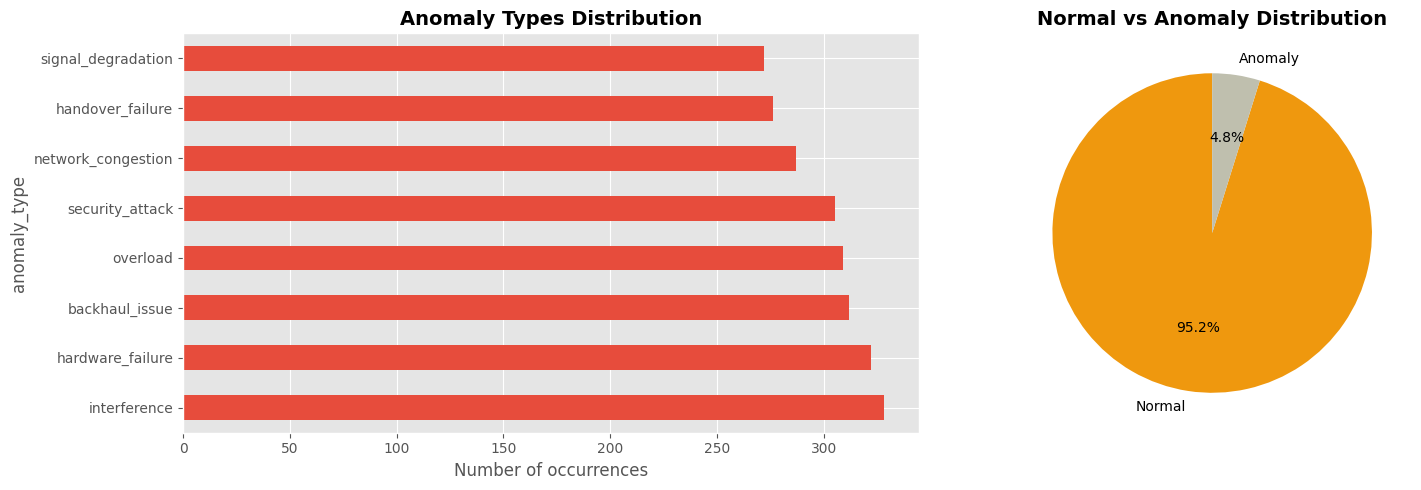

In [8]:
# Anomaly type distribution
print('🔴 Anomaly type distribution:')
type_counts = df['anomaly_type'].value_counts()
for t, c in type_counts.items():
    print(f'   {t:<35} {c:>6,}  ({c/len(df)*100:.2f}%)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Anomaly type distribution
type_counts[type_counts.index != 'normal'].plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Anomaly Types Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of occurrences')

# Chart 2: Normal vs anomaly
anomaly_counts = df['anomaly'].value_counts()
axes[1].pie(anomaly_counts, labels=['Normal', 'Anomaly'], autopct='%1.1f%%',
            colors=['#ef980e', '#bfbfae'], startangle=90)
axes[1].set_title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# =====================================================================

# PREPROCESSING

# =====================================================================


## 3. Feature Engineering & Scaling

In [9]:
# =====================================================================
# 3.1 Extract temporal components from timestamp
# =====================================================================

df['year']      = df['timestamp'].dt.year
df['month']     = df['timestamp'].dt.month
df['day']       = df['timestamp'].dt.day
df['hour']      = df['timestamp'].dt.hour
df['minute']    = df['timestamp'].dt.minute
df['second']    = df['timestamp'].dt.second
df['dayofweek'] = df['timestamp'].dt.dayofweek

print('Temporal columns extracted:')
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second', 'dayofweek']].head(5))


Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second  dayofweek
0 2024-01-01 00:00:23  2024      1    1     0       0      23          0
1 2024-01-01 00:05:07  2024      1    1     0       5       7          0
2 2024-01-01 00:10:21  2024      1    1     0      10      21          0
3 2024-01-01 00:14:31  2024      1    1     0      14      31          0
4 2024-01-01 00:20:09  2024      1    1     0      20       9          0


In [10]:
# =====================================================================
# 3.2 Drop non-predictive identifier columns
# =====================================================================

columns_to_drop = ['cell_id', 'ue_id']
df.drop(columns=columns_to_drop, inplace=True)

print(f'Dropped columns: {columns_to_drop}')
print(f'\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns')


Dropped columns: ['cell_id', 'ue_id']

New dataset dimensions: 50,000 rows x 27 columns


In [11]:
# =====================================================================
# 3.3 Encode slice_type (Label Encoding)
# =====================================================================

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print('slice_type encoding (Label Encoding):')
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f'   {label} -> {encoded}')


slice_type encoding (Label Encoding):
   URLLC -> 0
   eMBB -> 1
   mMTC -> 2


In [12]:
# =====================================================================
# 3.4 Encode anomaly_type — stored for evaluation only, never for training
# =====================================================================

df_clean = df.copy()

le_type    = LabelEncoder()
y_multi    = le_type.fit_transform(df_clean['anomaly_type'])
TYPE_NAMES = le_type.classes_
y_binary   = df_clean['anomaly'].values

print('anomaly_type encoding (Label Encoding):')
for label, encoded in zip(le_type.classes_, le_type.transform(le_type.classes_)):
    print(f'   {label:<35} -> {encoded}')

print(f'\n⚠️  y_multi and y_binary are stored for EVALUATION ONLY — never passed to any model.')


anomaly_type encoding (Label Encoding):
   backhaul_issue                      -> 0
   handover_failure                    -> 1
   hardware_failure                    -> 2
   interference                        -> 3
   network_congestion                  -> 4
   normal                              -> 5
   overload                            -> 6
   security_attack                     -> 7
   signal_degradation                  -> 8

⚠️  y_multi and y_binary are stored for EVALUATION ONLY — never passed to any model.


In [13]:
# =====================================================================
# 3.5 Feature matrix, StandardScaler, PCA pre-reduction
# =====================================================================

exclude_cols = ['timestamp', 'anomaly', 'anomaly_type', 'year']
FEATURE_COLS = [c for c in df_clean.columns if c not in exclude_cols]

X_full   = df_clean[FEATURE_COLS].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# PCA pre-reduction: retains 95% variance, speeds up clustering
pca_pre   = PCA(n_components=0.95, random_state=42)
X_cluster = pca_pre.fit_transform(X_scaled)

print('='*70)
print('VERIFICATION — STEP 3')
print('='*70)
print(f'\n  Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')
print(f'\n  X_scaled shape  : {X_scaled.shape}')
print(f'  X_cluster shape : {X_cluster.shape}  (PCA, 95% variance retained)')
print(f'  Variance retained : {pca_pre.explained_variance_ratio_.sum()*100:.1f}%')


VERIFICATION — STEP 3

  Features (23) : ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'month', 'day', 'hour', 'minute', 'second', 'dayofweek']

  X_scaled shape  : (50000, 23)
  X_cluster shape : (50000, 17)  (PCA, 95% variance retained)
  Variance retained : 95.9%


# =====================================================================

# CLUSTERING MODELS

# =====================================================================


> ⚠️ **Labels are never passed to any model.**
> `y_multi` and `y_binary` are used **only in Section 5** as evaluation oracles.


## 4. Clustering Models

### 4.1 K-Means

In [14]:
# =====================================================================
# 4.1.1 K-Means — k = N_CLUSTERS
# =====================================================================

print('='*70)
print(f'K-MEANS  (k = {N_CLUSTERS})')
print('='*70)

start_time = time.time()
kmeans     = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=20,
                    max_iter=500, random_state=42)
labels_km  = kmeans.fit_predict(X_cluster)
train_time_km = time.time() - start_time

print(f'\n  Training time : {train_time_km:.1f}s')
print(f'  Inertia       : {kmeans.inertia_:.2f}')
print(f'\n  Cluster sizes:')
for c, n in zip(*np.unique(labels_km, return_counts=True)):
    print(f'    Cluster {c:2d} : {n:>6,}  ({n/len(labels_km)*100:.1f}%)')

print('\n✅ K-Means done.')


K-MEANS  (k = 9)

  Training time : 1.0s
  Inertia       : 491581.31

  Cluster sizes:
    Cluster  0 :  7,235  (14.5%)
    Cluster  1 :  7,055  (14.1%)
    Cluster  2 :  9,331  (18.7%)
    Cluster  3 :  7,678  (15.4%)
    Cluster  4 : 10,195  (20.4%)
    Cluster  5 :    614  (1.2%)
    Cluster  6 :  7,583  (15.2%)
    Cluster  7 :     58  (0.1%)
    Cluster  8 :    251  (0.5%)

✅ K-Means done.


⏳ Computing elbow + silhouette for k = 2...13 (subsample = 8,000)...


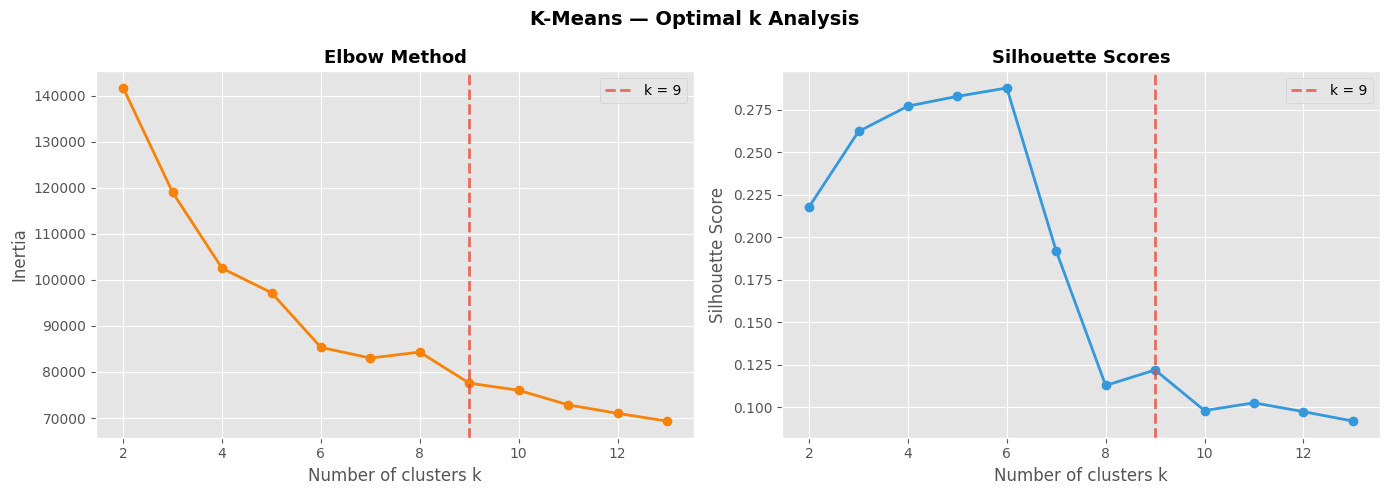

In [15]:
# =====================================================================
# 4.1.2 Elbow + Silhouette — validate k = N_CLUSTERS
# =====================================================================

K_RANGE = range(2, 14)
inertias, sil_scores = [], []

np.random.seed(42)
sub_idx = np.random.choice(len(X_cluster), size=min(8000, len(X_cluster)), replace=False)
X_sub   = X_cluster[sub_idx]

print(f'⏳ Computing elbow + silhouette for k = 2...13 (subsample = {len(sub_idx):,})...')
for k in K_RANGE:
    km_tmp  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbl_tmp = km_tmp.fit_predict(X_sub)
    inertias.append(km_tmp.inertia_)
    sil_scores.append(silhouette_score(X_sub, lbl_tmp, sample_size=3000))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), inertias, 'o-', color='#f68308', lw=2)
ax1.axvline(N_CLUSTERS, color='#e74c3c', ls='--', lw=2, alpha=0.8, label=f'k = {N_CLUSTERS}')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.legend()

ax2.plot(list(K_RANGE), sil_scores, 'o-', color='#3498db', lw=2)
ax2.axvline(N_CLUSTERS, color='#e74c3c', ls='--', lw=2, alpha=0.8, label=f'k = {N_CLUSTERS}')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores', fontsize=13, fontweight='bold')
ax2.legend()

plt.suptitle('K-Means — Optimal k Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.2 DBSCAN

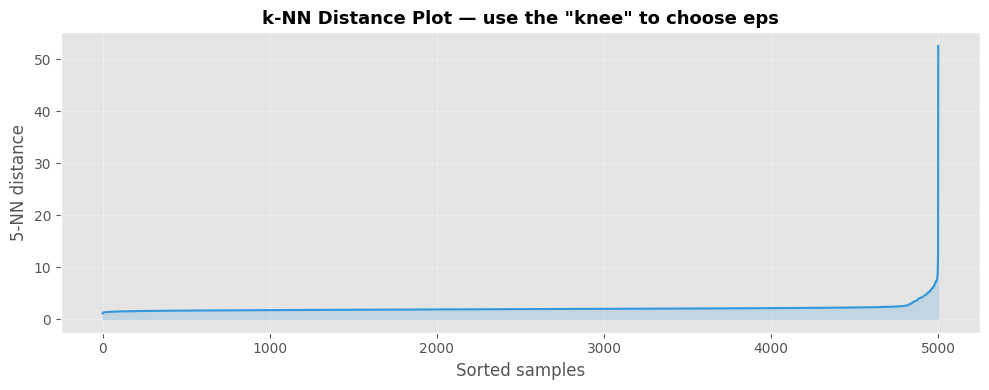

🔍 Suggested eps (90th percentile of 5-NN distances) : 2.2377
   Adjust EPS_VAL in the next cell if results look off.


In [16]:
# =====================================================================
# 4.2.1 DBSCAN — estimate eps from k-NN distance distribution
# =====================================================================
# Noise points (label = -1) are treated as anomalies.

np.random.seed(42)
db_sub_idx = np.random.choice(len(X_cluster), size=min(5000, len(X_cluster)), replace=False)
nn         = NearestNeighbors(n_neighbors=5)
nn.fit(X_cluster[db_sub_idx])
dists, _   = nn.kneighbors(X_cluster[db_sub_idx])
k_dists    = np.sort(dists[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dists, color='#3498db', lw=1.5)
plt.fill_between(range(len(k_dists)), k_dists, alpha=0.2, color='#3498db')
plt.xlabel('Sorted samples')
plt.ylabel('5-NN distance')
plt.title('k-NN Distance Plot — use the "knee" to choose eps', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

EPS_VAL = float(np.percentile(k_dists, 90))
print(f'🔍 Suggested eps (90th percentile of 5-NN distances) : {EPS_VAL:.4f}')
print(f'   Adjust EPS_VAL in the next cell if results look off.')


In [17]:
# =====================================================================
# 4.2.2 DBSCAN — fit
# =====================================================================
# Tune EPS_VAL and MIN_SAMPLES_DB based on the k-NN plot above.

EPS_VAL        = EPS_VAL     # from previous cell — override here if needed
MIN_SAMPLES_DB = 10

print('='*70)
print(f'DBSCAN  (eps = {EPS_VAL:.4f}, min_samples = {MIN_SAMPLES_DB})')
print('='*70)

start_time = time.time()
dbscan     = DBSCAN(eps=EPS_VAL, min_samples=MIN_SAMPLES_DB, n_jobs=-1)
labels_db  = dbscan.fit_predict(X_cluster)
train_time_db = time.time() - start_time

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = (labels_db == -1).sum()

print(f'\n  Training time   : {train_time_db:.1f}s')
print(f'  Clusters found  : {n_clusters_db}')
print(f'  Noise points    : {n_noise:,} ({n_noise/len(labels_db)*100:.2f}%)  <- treated as anomalies')
print(f'\n  Cluster sizes:')
for c, n in zip(*np.unique(labels_db, return_counts=True)):
    label = 'Noise' if c == -1 else f'Cluster {c}'
    print(f'    {label:<12} : {n:>6,}  ({n/len(labels_db)*100:.1f}%)')

print('\n✅ DBSCAN done.')


DBSCAN  (eps = 2.2377, min_samples = 10)

  Training time   : 1.4s
  Clusters found  : 2
  Noise points    : 1,914 (3.83%)  <- treated as anomalies

  Cluster sizes:
    Noise        :  1,914  (3.8%)
    Cluster 0    : 33,433  (66.9%)
    Cluster 1    : 14,653  (29.3%)

✅ DBSCAN done.


### 4.3 Gaussian Mixture Model (GMM)

In [18]:
# =====================================================================
# 4.3 Gaussian Mixture Model (GMM)
# =====================================================================
# Soft probabilistic cluster assignment — each sample gets a probability per component.

print('='*70)
print(f'GAUSSIAN MIXTURE MODEL  (n_components = {N_CLUSTERS})')
print('='*70)

start_time = time.time()
gmm        = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                              init_params='k-means++', n_init=5,
                              max_iter=200, random_state=42)
gmm.fit(X_cluster)
labels_gmm  = gmm.predict(X_cluster)
probs_gmm   = gmm.predict_proba(X_cluster)
train_time_gmm = time.time() - start_time

print(f'\n  Training time              : {train_time_gmm:.1f}s')
print(f'  Converged                  : {gmm.converged_}  ({gmm.n_iter_} iterations)')
print(f'  BIC                        : {gmm.bic(X_cluster):.2f}')
print(f'  AIC                        : {gmm.aic(X_cluster):.2f}')
print(f'  Mean assignment confidence : {probs_gmm.max(axis=1).mean()*100:.1f}%')
print('\n✅ GMM done.')


GAUSSIAN MIXTURE MODEL  (n_components = 9)

  Training time              : 7.6s
  Converged                  : True  (21 iterations)
  BIC                        : 687176.97
  AIC                        : 673612.15
  Mean assignment confidence : 93.6%

✅ GMM done.


### 4.4 Agglomerative Clustering

In [ ]:
# =====================================================================
# 4.4 Agglomerative Clustering (Ward linkage)
# =====================================================================
# Hierarchical — deterministic, no random initialization.

print('='*70)
print(f'AGGLOMERATIVE CLUSTERING  (k = {N_CLUSTERS}, linkage = ward)')
print('='*70)

start_time  = time.time()
agg         = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
labels_agg  = agg.fit_predict(X_cluster)
train_time_agg = time.time() - start_time

print(f'\n  Training time : {train_time_agg:.1f}s')
print(f'\n  Cluster sizes:')
for c, n in zip(*np.unique(labels_agg, return_counts=True)):
    print(f'    Cluster {c:2d} : {n:>6,}  ({n/len(labels_agg)*100:.1f}%)')

print('\n✅ Agglomerative Clustering done.')


AGGLOMERATIVE CLUSTERING  (k = 9, linkage = ward)


# =====================================================================

# CLUSTER-TO-LABEL MAPPING

# =====================================================================


## 5. Cluster-to-Label Mapping (Hungarian Algorithm)

The **Hungarian algorithm** finds the optimal one-to-one assignment between discovered cluster IDs
and ground-truth anomaly type names — maximising total overlap across all cluster-label pairs simultaneously.


In [ ]:
# =====================================================================
# 5.1 Hungarian matching utility
# =====================================================================

def hungarian_match(cluster_labels, true_labels, n_classes):
    '''
    Optimal assignment of cluster IDs to true class IDs using the Hungarian algorithm.
    Returns: (mapping dict: cluster_id -> class_id, remapped label array)
    '''
    unique_cl = [c for c in np.unique(cluster_labels) if c != -1]
    cost      = np.zeros((len(unique_cl), n_classes), dtype=int)

    for i, c in enumerate(unique_cl):
        for j in range(n_classes):
            cost[i, j] = -np.sum((cluster_labels == c) & (true_labels == j))

    row_ind, col_ind = linear_sum_assignment(cost)
    mapping  = {unique_cl[r]: col_ind[i] for i, r in enumerate(row_ind)}
    remapped = np.full_like(cluster_labels, fill_value=-1)
    for c_id, t_id in mapping.items():
        remapped[cluster_labels == c_id] = t_id

    return mapping, remapped

N_CLASSES = len(TYPE_NAMES)

mapping_km,  labels_km_mapped  = hungarian_match(labels_km,  y_multi, N_CLASSES)
mapping_gmm, labels_gmm_mapped = hungarian_match(labels_gmm, y_multi, N_CLASSES)
mapping_agg, labels_agg_mapped = hungarian_match(labels_agg, y_multi, N_CLASSES)
mapping_db,  labels_db_mapped  = hungarian_match(labels_db,  y_multi, N_CLASSES)

print('='*70)
print('HUNGARIAN MAPPING — K-MEANS  (cluster -> anomaly type)')
print('='*70)
for c, t in sorted(mapping_km.items()):
    print(f'   Cluster {c:2d}  ->  {TYPE_NAMES[t]}')

print()
print('='*70)
print('HUNGARIAN MAPPING — GMM  (cluster -> anomaly type)')
print('='*70)
for c, t in sorted(mapping_gmm.items()):
    print(f'   Cluster {c:2d}  ->  {TYPE_NAMES[t]}')


In [ ]:
# =====================================================================
# 5.2 Cluster-to-type confusion heatmaps (row-normalised)
# =====================================================================

def plot_cluster_heatmap(ax, cluster_labels, true_labels, type_names, title):
    valid   = cluster_labels != -1
    cm      = confusion_matrix(true_labels[valid], cluster_labels[valid])
    cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_norm, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                xticklabels=range(cm.shape[1]),
                yticklabels=type_names[:cm.shape[0]],
                cbar_kws={'label': 'Proportion'},
                linewidths=0.3, linecolor='white')
    ax.set_xlabel('Cluster ID')
    ax.set_ylabel('True anomaly type')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
plot_cluster_heatmap(axes[0, 0], labels_km,  y_multi, TYPE_NAMES, 'K-Means')
plot_cluster_heatmap(axes[0, 1], labels_db,  y_multi, TYPE_NAMES, 'DBSCAN')
plot_cluster_heatmap(axes[1, 0], labels_gmm, y_multi, TYPE_NAMES, 'GMM')
plot_cluster_heatmap(axes[1, 1], labels_agg, y_multi, TYPE_NAMES, 'Agglomerative')

plt.suptitle(
    'Cluster-to-Label Mapping Heatmaps\n(row-normalised: % of each true class per cluster)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


# =====================================================================

# EVALUATION

# =====================================================================


## 6. Evaluation & Model Comparison

In [ ]:
# =====================================================================
# 6.1 Clustering quality metrics
# =====================================================================
# Internal metrics: Silhouette, DBI  (no labels needed)
# External metrics: ARI, NMI         (compare against ground truth)

def compute_cluster_metrics(name, labels, true_labels, X):
    valid = labels != -1
    n_cl  = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).mean() * 100

    if valid.sum() < 2 or n_cl < 2:
        return {'Model': name, 'Silhouette': float('nan'), 'DBI': float('nan'),
                'ARI': float('nan'), 'NMI': float('nan'),
                'N Clusters': n_cl, 'Noise %': noise}

    sub = min(8000, valid.sum())
    return {
        'Model'      : name,
        'Silhouette' : silhouette_score(X[valid], labels[valid], sample_size=sub),
        'DBI'        : davies_bouldin_score(X[valid], labels[valid]),
        'ARI'        : adjusted_rand_score(true_labels[valid], labels[valid]),
        'NMI'        : normalized_mutual_info_score(true_labels[valid], labels[valid]),
        'N Clusters' : n_cl,
        'Noise %'    : noise,
    }

eval_df = pd.DataFrame([
    compute_cluster_metrics('K-Means',       labels_km,  y_multi, X_cluster),
    compute_cluster_metrics('DBSCAN',        labels_db,  y_multi, X_cluster),
    compute_cluster_metrics('GMM',           labels_gmm, y_multi, X_cluster),
    compute_cluster_metrics('Agglomerative', labels_agg, y_multi, X_cluster),
]).set_index('Model').sort_values('NMI', ascending=False)

print('='*70)
print('UNSUPERVISED CLUSTERING — EVALUATION SUMMARY')
print('='*70)
print(eval_df.to_string(float_format='{:.4f}'.format))
print()
print('─'*70)
print('📊 Metric guide:')
print('   Silhouette : ↑ better  [-1, 1]  — cluster compactness (no labels needed)')
print('   DBI        : ↓ better  [0, ∞)   — cluster separation  (no labels needed)')
print('   ARI        : ↑ better  [-1, 1]  — match vs ground truth')
print('   NMI        : ↑ better  [0, 1]   — shared information vs ground truth')
print('─'*70)
print(f'\n🏆 Best model (NMI) : {eval_df.index[0]}')
print(f'   NMI             : {eval_df["NMI"].max():.4f}')
print(f'   ARI             : {eval_df["ARI"].max():.4f}')


In [ ]:
# =====================================================================
# 6.2 Bar chart — metric comparison
# =====================================================================

metrics_to_plot = ['Silhouette', 'ARI', 'NMI']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#3498db', '#e67e22', '#9b59b6', '#e74c3c']

for ax, metric in zip(axes, metrics_to_plot):
    vals = eval_df[metric].fillna(0).values
    bars = ax.barh(eval_df.index, vals, color=colors, edgecolor='white', height=0.55)
    ax.set_xlim(-0.1, max(vals.max() * 1.2, 0.1))
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(max(v + 0.01, 0.01), bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Unsupervised Multi-Class Clustering — Model Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# =====================================================================
# 6.3 Per-class precision / recall — best model
# =====================================================================

BEST_MODEL  = eval_df.index[0]
best_mapped = {
    'K-Means'       : labels_km_mapped,
    'DBSCAN'        : labels_db_mapped,
    'GMM'           : labels_gmm_mapped,
    'Agglomerative' : labels_agg_mapped
}[BEST_MODEL]

print('='*70)
print(f'PER-CLASS RESULTS — {BEST_MODEL}')
print('='*70)
print(f'\n  {"Anomaly Type":<35} {"N True":>8} {"N Pred":>8} {"Precision":>10} {"Recall":>8}')
print('  ' + '─'*72)
for i, name in enumerate(TYPE_NAMES):
    tm   = y_multi == i
    pm   = best_mapped == i
    prec = (tm & pm).sum() / (pm.sum() + 1e-9)
    rec  = (tm & pm).sum() / (tm.sum() + 1e-9)
    print(f'  {name:<35} {int(tm.sum()):>8,} {int(pm.sum()):>8,} {prec:>10.3f} {rec:>8.3f}')


# =====================================================================

# DIMENSIONALITY REDUCTION & VISUALISATION

# =====================================================================


## 7. Dimensionality Reduction & Visualisation

Each projection shows **true anomaly types** (left) vs **best-model cluster assignments** (right).


In [ ]:
# =====================================================================
# 7.0 Subsample for visualisation
# =====================================================================

VIZ_SAMPLES = 5000
np.random.seed(42)
viz_idx = np.random.choice(len(X_cluster), size=min(VIZ_SAMPLES, len(X_cluster)), replace=False)

X_viz   = X_cluster[viz_idx]
y_viz   = y_multi[viz_idx]
cl_viz  = {
    'K-Means'       : labels_km,
    'DBSCAN'        : labels_db,
    'GMM'           : labels_gmm,
    'Agglomerative' : labels_agg
}[BEST_MODEL][viz_idx]

PALETTE = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6',
           '#1abc9c', '#f39c12', '#2980b9', '#8e44ad', '#16a085']

def scatter_multi(ax, coords, labels, label_names, title):
    for i, lbl in enumerate(sorted(set(labels) - {-1})):
        m    = labels == lbl
        name = label_names[lbl] if lbl < len(label_names) else f'C{lbl}'
        ax.scatter(coords[m, 0], coords[m, 1], c=PALETTE[i % len(PALETTE)],
                   s=8, alpha=0.5, label=name, edgecolors='none')
    if -1 in labels:
        m = labels == -1
        ax.scatter(coords[m, 0], coords[m, 1], c='lightgray',
                   s=4, alpha=0.3, label='Noise', edgecolors='none')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(markerscale=3, fontsize=7, ncol=2, loc='best')

print(f'📊 Visualisation sample : {len(viz_idx):,} points')
print(f'🏆 Best model (NMI)     : {BEST_MODEL}')


### 7.1 PCA (Principal Component Analysis)

In [ ]:
# =====================================================================
# 7.1 PCA — linear projection, fast
# =====================================================================

pca_viz    = PCA(n_components=2, random_state=42)
coords_pca = pca_viz.fit_transform(X_viz)
ev         = pca_viz.explained_variance_ratio_

print(f'📊 PCA explained variance:')
print(f'   PC1 : {ev[0]*100:.1f}%')
print(f'   PC2 : {ev[1]*100:.1f}%')
print(f'   Total : {sum(ev)*100:.1f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
scatter_multi(ax1, coords_pca, y_viz,  TYPE_NAMES,               'PCA — True Anomaly Types')
scatter_multi(ax2, coords_pca, cl_viz, [f'C{i}' for i in range(20)], f'PCA — {BEST_MODEL} Clusters')
for ax in (ax1, ax2):
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
plt.suptitle(f'PCA Projection  (n = {len(viz_idx):,} samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.2 t-SNE

In [ ]:
# =====================================================================
# 7.2 t-SNE — non-linear, reveals local cluster structure
# =====================================================================

print('⏳ Running t-SNE (this may take a few minutes)...')
start_time = time.time()

tsne        = TSNE(n_components=2, perplexity=40, n_iter=1000,
                   random_state=42, n_jobs=-1)
coords_tsne = tsne.fit_transform(X_viz)

print(f'✅ t-SNE complete in {time.time()-start_time:.1f}s  |  KL divergence: {tsne.kl_divergence_:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
scatter_multi(ax1, coords_tsne, y_viz,  TYPE_NAMES,               't-SNE — True Anomaly Types')
scatter_multi(ax2, coords_tsne, cl_viz, [f'C{i}' for i in range(20)], f't-SNE — {BEST_MODEL} Clusters')
for ax in (ax1, ax2):
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
plt.suptitle(f't-SNE Projection  (n = {len(viz_idx):,}, perplexity = 40)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.3 UMAP *(optional)*

In [ ]:
# =====================================================================
# 7.3 UMAP — fast, preserves both local and global structure
# =====================================================================
# To enable: pip install umap-learn
# Then set USE_UMAP = True

USE_UMAP = False    # <- set to True if umap-learn is installed

if USE_UMAP:
    import umap
    print('⏳ Running UMAP...')
    start_time = time.time()

    reducer     = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
    coords_umap = reducer.fit_transform(X_viz)
    print(f'✅ UMAP complete in {time.time()-start_time:.1f}s')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    scatter_multi(ax1, coords_umap, y_viz,  TYPE_NAMES,               'UMAP — True Anomaly Types')
    scatter_multi(ax2, coords_umap, cl_viz, [f'C{i}' for i in range(20)], f'UMAP — {BEST_MODEL} Clusters')
    for ax in (ax1, ax2):
        ax.set_xlabel('UMAP Dim 1')
        ax.set_ylabel('UMAP Dim 2')
    plt.suptitle(f'UMAP Projection  (n = {len(viz_idx):,})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  UMAP skipped.')
    print('   To enable: pip install umap-learn  then set USE_UMAP = True above.')


# =====================================================================

# SUMMARY

# =====================================================================


## 8. Summary & Results

In [ ]:
# =====================================================================
# 8. Final summary
# =====================================================================

print('='*70)
print('NOTEBOOK 2 — UNSUPERVISED MULTI-CLASS CLUSTERING — FINAL RESULTS')
print('='*70)
print()
print(eval_df.to_string(float_format='{:.4f}'.format))
print()
print('─'*70)
print(f'🏆 Best model (NMI) : {eval_df.index[0]}')
print(f'   NMI             : {eval_df["NMI"].max():.4f}')
print(f'   ARI             : {eval_df["ARI"].max():.4f}')
print(f'   Silhouette      : {eval_df.loc[eval_df.index[0], "Silhouette"]:.4f}')
print('─'*70)
print()
print('📊 Training times:')
print(f'   K-Means              : {train_time_km:.1f}s')
print(f'   DBSCAN               : {train_time_db:.1f}s')
print(f'   GMM                  : {train_time_gmm:.1f}s')
print(f'   Agglomerative        : {train_time_agg:.1f}s')
